# Quantifying Curtailment Impact on PPA Pricing Data on Brazilian wind power assets in 2025

Exploratory analysis of the economic impact of curtailment on a 688 MW wind complex (2025). The study evaluates physical restriction patterns and financial exposure to PPA contracts and spot prices (PLD), using public data from ONS, EPE and CCEE to quantify risk and implied contract price adjustments.

#### **DATA IMPORT**
##### **1. PLD** https://dadosabertos.ccee.org.br/dataset/pld_horario

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# ---------------------------------------------------------------------
# 1. Load PLD hourly data (2025)
# ---------------------------------------------------------------------

BASE_PATH = Path("Enter your directory")
pld_path = BASE_PATH / "pld_horario_2025.csv"

df_pld = pd.read_csv(pld_path, sep=";")

# ---------------------------------------------------------------------
# 2. Extract year and month from reference field (YYYYMM format)
# ---------------------------------------------------------------------

df_pld["year"] = df_pld["MES_REFERENCIA"] // 100
df_pld["month"] = df_pld["MES_REFERENCIA"] % 100

# ---------------------------------------------------------------------
# 3. Standardize column names
#    Translation applied only at modeling layer
# ---------------------------------------------------------------------

df_pld = df_pld.rename(columns={
    "DIA": "day",
    "HORA": "hour",
    "SUBMERCADO": "submarket",
    "PLD_HORA": "pld_hour"
})

# Normalize submarket naming
df_pld["submarket"] = df_pld["submarket"].replace({"NORDESTE": "NE", "SUDESTE": "SE", "NORTE":"N", "SUL":"S"})

# ---------------------------------------------------------------------
# 4. Build hourly timestamp
# ---------------------------------------------------------------------

df_pld["time"] = pd.to_datetime(dict(
    year=df_pld["year"],
    month=df_pld["month"],
    day=df_pld["day"],
    hour=df_pld["hour"]
))

# Keep only relevant fields
df_pld = df_pld[["time", "submarket", "pld_hour"]]

# Filter for Northeast submarket (case study region)
df_pld = df_pld[df_pld["submarket"] == "NE"]

# Sort chronologically
df_pld = df_pld.sort_values("time")

# ---------------------------------------------------------------------
# 5. Convert hourly PLD to 30-min resolution
#    (Assumption: constant price within the hour)
# ---------------------------------------------------------------------

df_pld_30min = df_pld.loc[df_pld.index.repeat(2)].copy()

df_pld_30min["offset_min"] = (
    df_pld_30min.groupby(level=0).cumcount() * 30
)

df_pld_30min["time"] = (
    df_pld_30min["time"] +
    pd.to_timedelta(df_pld_30min["offset_min"], unit="m")
)

df_pld_30min = (
    df_pld_30min
    .drop(columns="offset_min")
    .reset_index(drop=True)
    .rename(columns={"pld_hour": "pld_30min"})
)

#### **DATA IMPORT**
##### **2. Constrained Off and Verified Generation - ONS** https://dados.ons.org.br/dataset/restricao_coff_eolica_usi

In [3]:
# ---------------------------------------------------------------------
# 1. Load ONS wind restriction data (2025)
#    Source: ONS semi-hourly operational dataset
# ---------------------------------------------------------------------

wind_files = sorted(BASE_PATH.glob("RESTRICAO_COFF_EOLICA_2025_*.parquet"))

df_wind = pd.concat(
    [pd.read_parquet(file) for file in wind_files],
    ignore_index=True
)

# ---------------------------------------------------------------------
# 2. Standardize column names and time format
#    Original data resolution: 30-minute intervals
# ---------------------------------------------------------------------

df_wind = df_wind.rename(columns={
    "din_instante": "time",
    "id_subsistema": "submarket",
    "val_geracao": "generation",
    "val_geracaolimitada": "permitted_generation",
    "val_geracaoreferencia": "reference_generation",
    "cod_razaorestricao": "restriction_reason"
})

df_wind["time"] = pd.to_datetime(df_wind["time"])

# ---------------------------------------------------------------------
# 3. Filter target wind complex (Campo Largo I, II and aggregated)
#    Assumption: turbines available at nominal capacity (100% availability)
# ---------------------------------------------------------------------

target_plants = ["CJU_BACLA", "CJU_BACLA2", "CJU_BAE4CLA"]
df_wind = df_wind[df_wind["id_ons"].isin(target_plants)]

# ---------------------------------------------------------------------
# 4. Ensure numeric fields
# ---------------------------------------------------------------------

numeric_cols = [
    "generation",
    "permitted_generation",
    "reference_generation"
]

for col in numeric_cols:
    df_wind[col] = pd.to_numeric(df_wind[col], errors="coerce")

# ---------------------------------------------------------------------
# 5. Compute observed curtailment (30-min basis)
#    Curtailment defined as:
#    reference_generation - actual_generation
#    when restriction is binding
# ---------------------------------------------------------------------

df_wind["curtailment_30min"] = np.where(
    df_wind["permitted_generation"].notna() &
    (df_wind["reference_generation"] > df_wind["generation"]),
    df_wind["reference_generation"] - df_wind["generation"],
    0.0
)

# Keep relevant fields
df_wind = df_wind[[
    "time",
    "submarket",
    "id_ons",
    "restriction_reason",
    "generation",
    "permitted_generation",
    "curtailment_30min",
    "reference_generation"
]].copy()

# ---------------------------------------------------------------------
# 6. Aggregate Campo Largo I and II into single asset
#    New consolidated ID: CJU_BAE4CLA
# ---------------------------------------------------------------------

old_ids = ["CJU_BACLA", "CJU_BACLA2"]
new_id = "CJU_BAE4CLA"

mask_old = df_wind["id_ons"].isin(old_ids)
df_to_aggregate = df_wind[mask_old].copy()

# Aggregation rules:
# - Sum numeric variables
# - Preserve first submarket and restriction reason
# - Replace plant ID with consolidated ID

agg_rules = {
    col: "sum"
    for col in df_to_aggregate.select_dtypes(include="number").columns
}

# Special handling:
# permitted_generation:
# NaN = no restriction
# 0   = fully disconnected
# >0  = maximum allowed generation

if "permitted_generation" in agg_rules:
    agg_rules["permitted_generation"] = lambda x: x.sum(min_count=1)

agg_rules.update({
    "submarket": "first",
    "restriction_reason": "first",
    "id_ons": lambda x: new_id
})

df_combined = (
    df_to_aggregate
    .groupby("time")
    .agg(agg_rules)
    .reset_index()
)

# Remove original units and append consolidated asset
df_wind = df_wind[~mask_old]
df_wind = pd.concat([df_wind, df_combined], ignore_index=True)
df_wind = df_wind.sort_values("time")

#### **PREMIUM CALCULATION**


In [4]:
# ---------------------------------------------------------------------
# 1. Filter energy-related curtailment events (ENE)
# ---------------------------------------------------------------------

df_energy = (
    df_wind
    .query("restriction_reason == 'ENE'")
    .copy()
)

df_energy["curtailment_30min"] = (
    df_energy["curtailment_30min"].fillna(0.0)
)

# ---------------------------------------------------------------------
# 2. Merge wind data with PLD (30-min resolution)
# ---------------------------------------------------------------------

df = df_energy.merge(
    df_pld_30min,
    on="time",
    how="left"
)

df["pld_30min"] = df["pld_30min"].fillna(0.0)

# ---------------------------------------------------------------------
# 3. Firm Energy assumption (MWmed)
# ---------------------------------------------------------------------

FIRM_ENERGY = 359.0  # MWmed

# ---------------------------------------------------------------------
# 4. Define operating conditions
# ---------------------------------------------------------------------

df["has_curtailment"] = df["curtailment_30min"] > 0
df["sufficient_wind"] = df["reference_generation"] >= FIRM_ENERGY

# Energy deficits (MWmed)

df["deficit_without_curtailment"] = (
    FIRM_ENERGY - df["reference_generation"]
).clip(lower=0)

df["deficit_with_curtailment"] = (
    FIRM_ENERGY -
    (df["reference_generation"] - df["curtailment_30min"])
).clip(lower=0)

# ---------------------------------------------------------------------
# 5. Curtailment cost decomposition
#    Convert MWmed (30-min) → MWh by dividing by 2
# ---------------------------------------------------------------------

df["causal_curtailment_cost"] = np.where(
    df["has_curtailment"] & df["sufficient_wind"],
    df["deficit_with_curtailment"] * df["pld_30min"] / 2,
    0.0
)

df["incremental_risk_cost"] = np.where(
    ~df["sufficient_wind"] & df["has_curtailment"],
    (
        df["deficit_with_curtailment"] -
        df["deficit_without_curtailment"]
    ) * df["pld_30min"] / 2,
    0.0
)

df["total_curtailment_cost"] = (
    df["causal_curtailment_cost"] +
    df["incremental_risk_cost"]
)

# ---------------------------------------------------------------------
# 6. Annual consolidation (2025)
# ---------------------------------------------------------------------

causal_cost = df["causal_curtailment_cost"].sum()
incremental_cost = df["incremental_risk_cost"].sum()
total_cost = df["total_curtailment_cost"].sum()

contracted_energy_year = FIRM_ENERGY * 8760  # MWh/year

causal_risk_premium = causal_cost / contracted_energy_year
incremental_risk_premium = incremental_cost / contracted_energy_year
total_risk_premium = total_cost / contracted_energy_year

# ---------------------------------------------------------------------
# 7. Results
# ---------------------------------------------------------------------

print(f"Causal curtailment cost (2025): R$ {causal_cost:,.2f}")
print(f"Causal PPA premium: {causal_risk_premium:.2f} R$/MWh")

print(f"Incremental risk cost (2025): R$ {incremental_cost:,.2f}")
print(f"Incremental PPA premium: {incremental_risk_premium:.2f} R$/MWh")

print(f"Total curtailment cost (2025): R$ {total_cost:,.2f}")
print(f"Total implied PPA premium: {total_risk_premium:.2f} R$/MWh")

Causal curtailment cost (2025): R$ 8,983,816.81
Causal PPA premium: 2.86 R$/MWh
Incremental risk cost (2025): R$ 6,721,995.91
Incremental PPA premium: 2.14 R$/MWh
Total curtailment cost (2025): R$ 15,705,812.72
Total implied PPA premium: 4.99 R$/MWh


#### **INTRADAY PLOT**


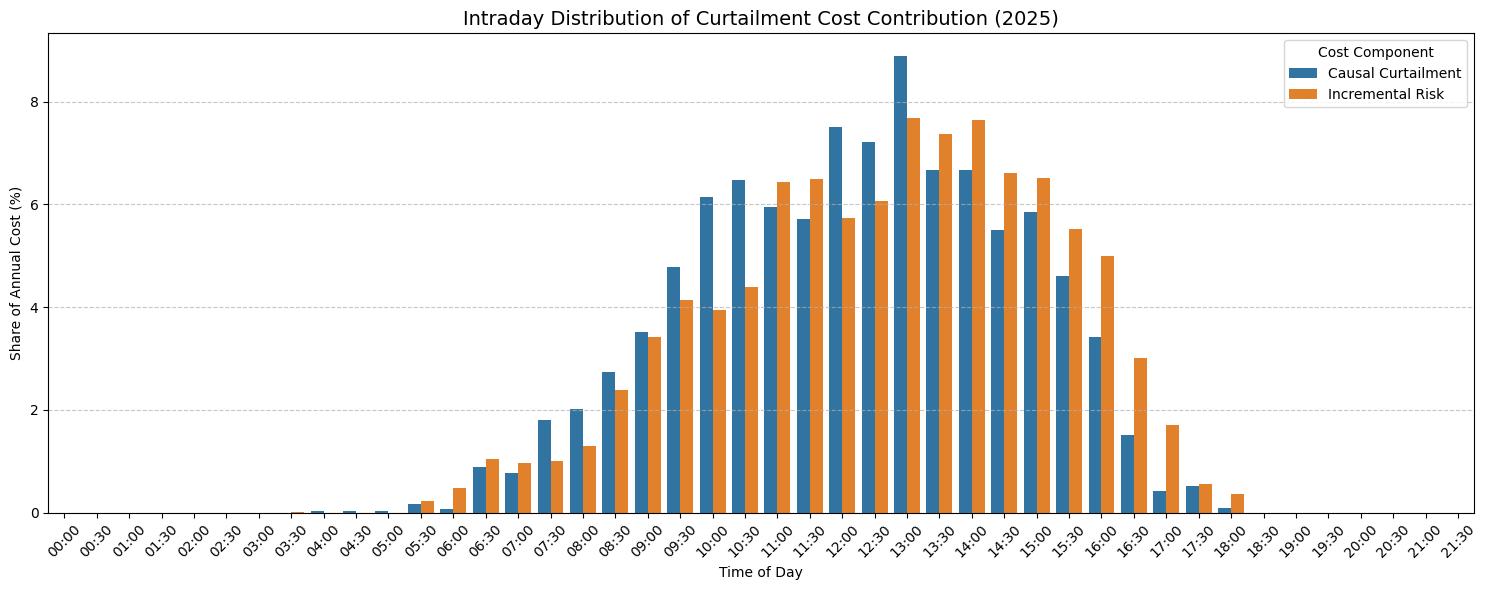

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------------
# 1. Prepare time-of-day aggregation
# ---------------------------------------------------------------------

df["period"] = df["time"].dt.strftime("%H:%M")

df_summary = df[["time", "generation", "permitted_generation", "reference_generation", "curtailment_30min", 
                "causal_curtailment_cost","incremental_risk_cost", "pld_30min", "total_curtailment_cost"]]

df_grouped = (
    df.groupby("period")[[
        "causal_curtailment_cost",
        "incremental_risk_cost"
    ]]
    .sum()
    .reset_index()
)

# ---------------------------------------------------------------------
# 2. Convert to percentage contribution
# ---------------------------------------------------------------------

total_causal = df_grouped["causal_curtailment_cost"].sum()
total_incremental = df_grouped["incremental_risk_cost"].sum()

df_grouped["causal_pct"] = (
    df_grouped["causal_curtailment_cost"] / total_causal * 100
)

df_grouped["incremental_pct"] = (
    df_grouped["incremental_risk_cost"] / total_incremental * 100
)

# Keep only percentage columns for plotting
df_plot = df_grouped[[
    "period",
    "causal_pct",
    "incremental_pct"
]]

# Convert to long format for seaborn
df_melted = df_plot.melt(
    id_vars="period",
    var_name="cost_type",
    value_name="percentage"
)

df_melted["cost_type"] = df_melted["cost_type"].map({
    "causal_pct": "Causal Curtailment",
    "incremental_pct": "Incremental Risk"
})

# ---------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------

plt.figure(figsize=(15, 6))

sns.barplot(
    data=df_melted,
    x="period",
    y="percentage",
    hue="cost_type"
)

plt.title(
    "Intraday Distribution of Curtailment Cost Contribution (2025)",
    fontsize=14
)

plt.xlabel("Time of Day")
plt.ylabel("Share of Annual Cost (%)")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Cost Component")

plt.tight_layout()
plt.show()

#### **DISTRIBUTION PLOT**


/var/folders/gm/wbj68qhj17x0qs3dpm2gkpj40000gn/T/ipykernel_35143/512385777.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_summary["premium_impact_pct"] = (


Average impact: 218.6% of annual premium
VaR (95%): 874.9% of annual premium
CVaR (95%): 1361.3% of annual premium


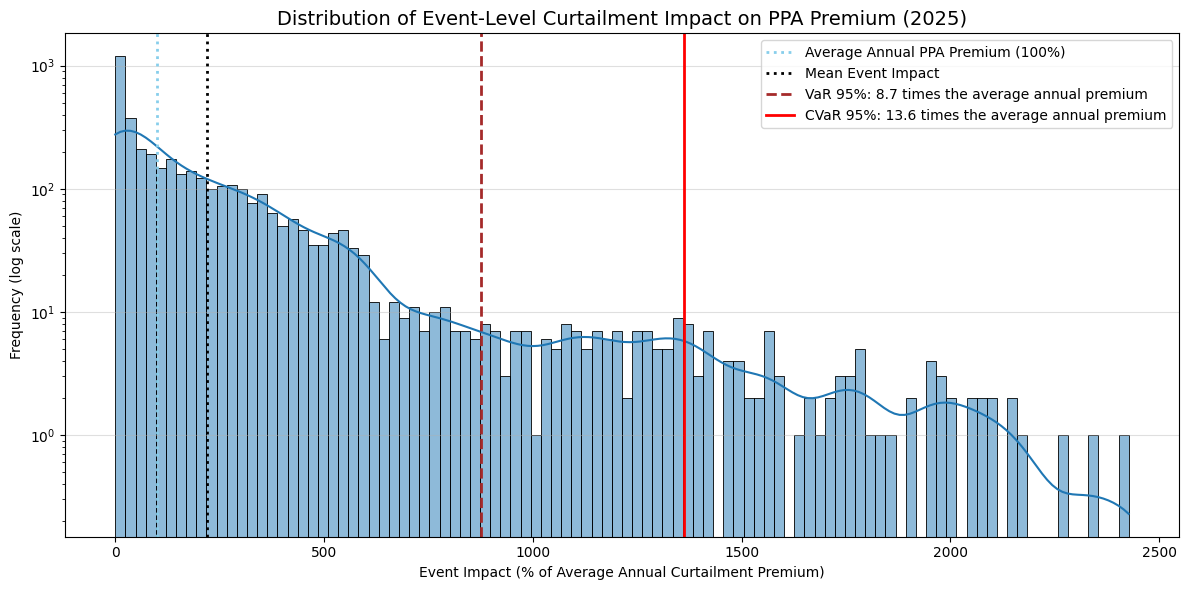

In [6]:
# ---------------------------------------------------------------------
# 1. Event-level premium impact (relative to annual premium)
# ---------------------------------------------------------------------

df_summary["premium_impact_pct"] = (
    (df_summary["total_curtailment_cost"] / FIRM_ENERGY)
    / total_risk_premium
) * 100

# ---------------------------------------------------------------------
# 2. Risk metrics (VaR and CVaR)
# ---------------------------------------------------------------------

CONFIDENCE_LEVEL = 0.95

var_95_pct = df_summary["premium_impact_pct"].quantile(CONFIDENCE_LEVEL)

cvar_95_pct = (
    df_summary[df_summary["premium_impact_pct"] >= var_95_pct]
    ["premium_impact_pct"]
    .mean()
)

avg_pct = df_summary["premium_impact_pct"].mean()

print(f"Average impact: {avg_pct:.1f}% of annual premium")
print(f"VaR (95%): {var_95_pct:.1f}% of annual premium")
print(f"CVaR (95%): {cvar_95_pct:.1f}% of annual premium")

# ---------------------------------------------------------------------
# 3. Distribution plot
# ---------------------------------------------------------------------

plt.figure(figsize=(12, 6))

sns.histplot(
    df_summary["premium_impact_pct"],
    kde=True,
    bins=100
)

# Reference lines

plt.axvline(
    100,
    linestyle=":",
    linewidth=2,
    label="Average Annual PPA Premium (100%)",
    color='skyblue'
)

plt.axvline(
    avg_pct,
    linestyle=":",
    linewidth=2,
    label="Mean Event Impact",
    color='black'
)

plt.axvline(
    var_95_pct,
    linestyle="--",
    linewidth=2,
    label=f"VaR 95%: {var_95_pct/100:.1f} times the average annual premium",
    color='brown'
)

plt.axvline(
    cvar_95_pct,
    linestyle="-",
    linewidth=2,
    label=f"CVaR 95%: {cvar_95_pct/100:.1f} times the average annual premium",
    color='red'
)

plt.yscale("log")

plt.title(
    "Distribution of Event-Level Curtailment Impact on PPA Premium (2025)",
    fontsize=14
)

plt.xlabel(
    "Event Impact (% of Average Annual Curtailment Premium)"
)

plt.ylabel("Frequency (log scale)")
plt.legend()
plt.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()